# Exploration — Dataset Mart Jürisoo + Calcul ELO
Pipeline : chargement → nettoyage → calcul ELO chronologique → équipes CdM 2026 → visualisation

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'

## 1. Chargement des données

In [74]:
# Chemin relatif depuis ml/notebooks/ → remonte deux niveaux vers ml/data/
df = pd.read_csv('../../ml/data/results.csv', parse_dates=['date'])

print(f'Matchs chargés : {len(df):,}')
print(f'Période        : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Équipes uniques: {pd.concat([df["home_team"], df["away_team"]]).nunique()}')
df.head()

Matchs chargés : 49,287
Période        : 1872-11-30 → 2026-06-27
Équipes uniques: 333


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [75]:
# Exclure les matchs futurs pré-remplis sans score (ex. CdM 2026 dans le dataset)
before = len(df)
df = df.dropna(subset=['home_score', 'away_score']).reset_index(drop=True)
print(f'{before - len(df)} matchs sans score exclus → {len(df):,} matchs conservés')


72 matchs sans score exclus → 49,215 matchs conservés


In [76]:
# Aperçu des types de tournois présents dans le dataset
print(df['tournament'].value_counts().head(20).to_string())

tournament
Friendly                                18252
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                            964
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368


## 2. Calcul des ELO ratings

On parcourt tous les matchs **dans l'ordre chronologique** (obligatoire — l'ELO d'un match dépend de tous les matchs précédents).

Formule :
```
expected_home = 1 / (1 + 10^((elo_away - elo_home) / 400))
score         = 1 (victoire dom.) | 0.5 (nul) | 0 (défaite dom.)
Δ_home        = K × (score − expected_home)
Δ_away        = K × ((1−score) − (1−expected_home))
```

Facteur K par type de compétition :
- **40** → tournoi majeur (Coupe du Monde, Coupe continentale)
- **30** → match de qualification
- **20** → match amical ou autre

In [77]:
# --- Définition du facteur K ---
MAJOR_KEYWORDS = [
    'FIFA World Cup', 'UEFA Euro', 'Copa América',
    'Africa Cup of Nations', 'African Cup of Nations',
    'Asian Cup', 'AFC Asian Cup',
    'Gold Cup', 'CONCACAF Gold Cup',
    'Oceania Nations Cup',
]
QUAL_KEYWORDS = ['qualification', 'Qualification', 'qualifier', 'Qualifier']

def get_k(tournament: str) -> int:
    # Tester qualification en premier : 'FIFA World Cup qualification' → K=30, pas K=40
    if any(kw in tournament for kw in QUAL_KEYWORDS):
        return 30
    if any(kw in tournament for kw in MAJOR_KEYWORDS):
        return 40
    return 20

# Vérification rapide
for t in ['FIFA World Cup', 'FIFA World Cup qualification', 'UEFA Euro',
          'UEFA Euro qualification', 'Friendly', 'Copa América', 'UEFA Nations League']:
    print(f'K={get_k(t):2d}  →  {t}')

K=40  →  FIFA World Cup
K=30  →  FIFA World Cup qualification
K=40  →  UEFA Euro
K=30  →  UEFA Euro qualification
K=20  →  Friendly
K=40  →  Copa América
K=20  →  UEFA Nations League


In [78]:
# --- Tri chronologique (obligatoire avant tout calcul ELO) ---
df = df.sort_values('date').reset_index(drop=True)

elo_current  = {}      # état courant {team: elo}
ELO_INIT     = 1500.0
history_rows = []

for _, row in df.iterrows():
    home, away, date = row['home_team'], row['away_team'], row['date']

    elo_h = elo_current.get(home, ELO_INIT)
    elo_a = elo_current.get(away, ELO_INIT)

    expected_home = 1.0 / (1.0 + 10.0 ** ((elo_a - elo_h) / 400.0))

    if   row['home_score'] > row['away_score']: score = 1.0
    elif row['home_score'] == row['away_score']: score = 0.5
    else:                                        score = 0.0

    K = get_k(row['tournament'])
    new_elo_h = elo_h + K * (score - expected_home)
    new_elo_a = elo_a + K * ((1.0 - score) - (1.0 - expected_home))

    elo_current[home] = new_elo_h
    elo_current[away] = new_elo_a

    history_rows.append({'date': date, 'team': home, 'elo': new_elo_h})
    history_rows.append({'date': date, 'team': away, 'elo': new_elo_a})

elo_history = pd.DataFrame(history_rows)
print(f'Lignes dans elo_history : {len(elo_history):,}')
elo_history.head(6)

Lignes dans elo_history : 98,430


,date,team,elo
0,1872-11-30,Scotland,1500.000000
1,1872-11-30,England,1500.000000
2,1873-03-08,England,1510.000000
3,1873-03-08,Scotland,1490.000000
4,1874-03-07,Scotland,1500.575011
5,1874-03-07,England,1499.424989


In [79]:
# Classement ELO actuel — dernier ELO connu de chaque équipe
elo_latest = (
    elo_history.sort_values('date')
    .groupby('team', as_index=False).last()
    .sort_values('elo', ascending=False)
    .reset_index(drop=True)
)
elo_latest.index += 1
print('Top 20 ELO actuels :')
print(elo_latest[['team', 'elo']].head(20).to_string())

Top 20 ELO actuels :
           team          elo
1         Spain  2039.840823
2     Argentina  2026.707088
3        France  1989.439476
4       England  1935.552521
5        Brazil  1919.577229
6   Netherlands  1907.683709
7       Germany  1906.972741
8      Portugal  1903.491437
9      Colombia  1902.536577
10      Morocco  1889.779887
11        Japan  1881.192155
12      Ecuador  1866.273578
13      Croatia  1861.813467
14       Mexico  1851.477659
15      Belgium  1849.797644
16        Italy  1849.494193
17      Uruguay  1848.082254
18      Senegal  1835.254878
19  Switzerland  1830.841292
20       Turkey  1828.252848


## 3. Évolution ELO des 6 grandes nations (1990 → aujourd'hui)

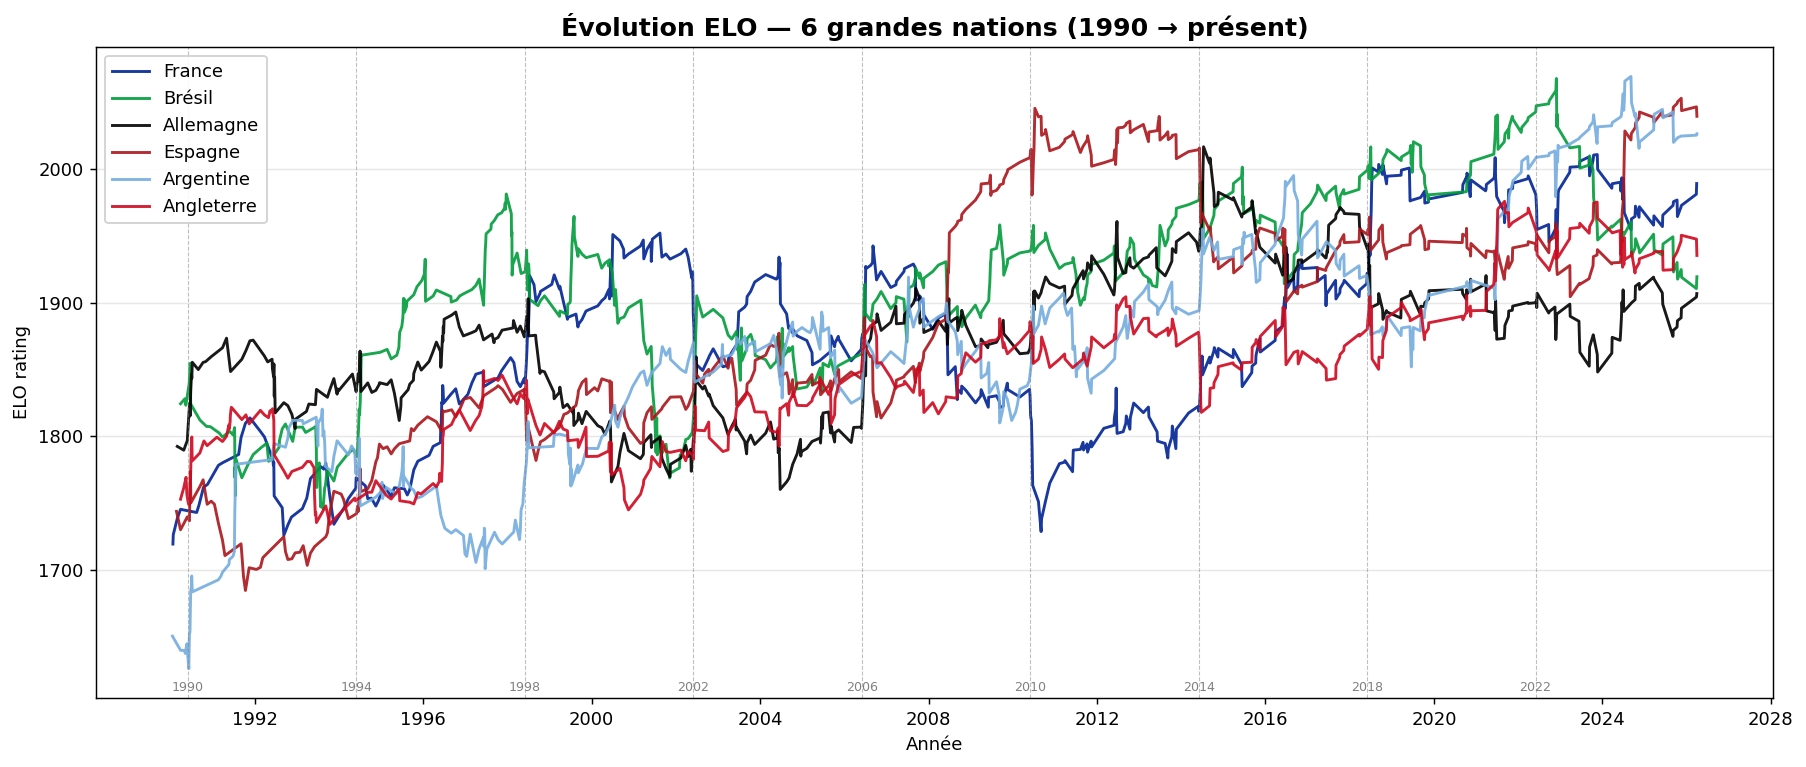

Graphique sauvegardé → ml/elo_evolution.png


In [80]:
NATIONS = ['France', 'Brazil', 'Germany', 'Spain', 'Argentina', 'England']
COLORS  = ['#002395', '#009C3B', '#000000', '#AA151B', '#74ACDF', '#CF081F']
LABELS  = ['France', 'Brésil', 'Allemagne', 'Espagne', 'Argentine', 'Angleterre']

mask = elo_history['team'].isin(NATIONS) & (elo_history['date'] >= '1990-01-01')
elo_6 = elo_history[mask].copy()

fig, ax = plt.subplots(figsize=(14, 6))
for nation, color, label in zip(NATIONS, COLORS, LABELS):
    data = elo_6[elo_6['team'] == nation].sort_values('date')
    ax.plot(data['date'], data['elo'], label=label, color=color, linewidth=1.6, alpha=0.9)

for yr in [1990, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022]:
    ax.axvline(pd.Timestamp(f'{yr}-06-01'), color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
    ax.text(pd.Timestamp(f'{yr}-06-01'), ax.get_ylim()[0] + 5, str(yr),
            fontsize=7, color='gray', ha='center')

ax.set_title('Évolution ELO — 6 grandes nations (1990 → présent)', fontsize=14, fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('ELO rating')
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../elo_evolution.png', bbox_inches='tight')
plt.show()
print('Graphique sauvegardé → ml/elo_evolution.png')

## 4. Vérification des données — matchs Coupe du Monde

In [81]:
wc = df[df['tournament'] == 'FIFA World Cup'].copy()
print(f'Matchs World Cup : {len(wc)}')
print(f'Editions         : {sorted(wc["date"].dt.year.unique())}')
print()

wc['result'] = wc.apply(
    lambda r: 'Domicile/Neutre' if r['home_score'] > r['away_score']
              else ('Nul' if r['home_score'] == r['away_score'] else 'Extérieur'),
    axis=1
)
print('Distribution des résultats (World Cup, phase finale) :')
print(wc['result'].value_counts(normalize=True).map('{:.1%}'.format).to_string())

Matchs World Cup : 964
Editions         : [1930, 1934, 1938, 1950, 1954, 1958, 1962, 1966, 1970, 1974, 1978, 1982, 1986, 1990, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022]

Distribution des résultats (World Cup, phase finale) :
result
Domicile/Neutre    45.5%
Extérieur          32.3%
Nul                22.2%


In [82]:
df['result'] = df.apply(
    lambda r: 'Home' if r['home_score'] > r['away_score']
              else ('Draw' if r['home_score'] == r['away_score'] else 'Away'),
    axis=1
)
print('Distribution globale (tous tournois) :')
print(df['result'].value_counts(normalize=True).map('{:.1%}'.format).to_string())
print()

df['decade'] = (df['date'].dt.year // 10) * 10
print('Matchs par décennie :')
print(df.groupby('decade').size().to_string())

Distribution globale (tous tournois) :
result
Home    49.0%
Away    28.3%
Draw    22.8%

Matchs par décennie :
decade
1870      13
1880      55
1890      59
1900     137
1910     330
1920     828
1930    1079
1940     833
1950    1651
1960    2971
1970    4133
1980    5025
1990    6944
2000    9525
2010    9756
2020    5876


## 5. Équipes qualifiées CdM 2026 — mapping des noms

Les noms officiels FIFA peuvent différer de ceux utilisés dans `results.csv`.
On construit un mapping explicite, on vérifie que toutes les équipes sont trouvées,
puis on filtre le classement ELO aux 48 équipes qualifiées.

In [83]:
WC2026_FIFA = {
    'Co-hôtes':  ['Canada', 'Mexico', 'USA'],
    'AFC':       ['Australia', 'Iraq', 'IR Iran', 'Japan', 'Jordan',
                  'Korea Republic', 'Qatar', 'Saudi Arabia', 'Uzbekistan'],
    'CAF':       ['Algeria', 'Cabo Verde', 'Congo DR', "Côte d'Ivoire",
                  'Egypt', 'Ghana', 'Morocco', 'Senegal', 'South Africa', 'Tunisia'],
    'CONCACAF':  ['Curaçao', 'Haiti', 'Panama'],
    'CONMEBOL':  ['Argentina', 'Brazil', 'Colombia', 'Ecuador', 'Paraguay', 'Uruguay'],
    'OFC':       ['New Zealand'],
    'UEFA':      ['Austria', 'Belgium', 'Bosnia and Herzegovina', 'Croatia',
                  'Czechia', 'England', 'France', 'Germany', 'Netherlands',
                  'Norway', 'Portugal', 'Scotland', 'Spain', 'Sweden',
                  'Switzerland', 'Türkiye'],
}

# Seuls les 8 noms qui divergent réellement entre FIFA et results.csv
# Bosnia and Herzegovina et Curaçao sont identiques dans les deux nomenclatures
FIFA_TO_DATASET = {
    'USA':            'United States',
    'IR Iran':        'Iran',
    'Korea Republic': 'South Korea',
    'Cabo Verde':     'Cape Verde',
    'Congo DR':       'DR Congo',
    "Côte d'Ivoire":  'Ivory Coast',
    'Czechia':        'Czech Republic',
    'Türkiye':        'Turkey',
}

wc_rows = []
for conf, teams in WC2026_FIFA.items():
    for t in teams:
        wc_rows.append({
            'confederation': conf,
            'fifa_name':     t,
            'dataset_name':  FIFA_TO_DATASET.get(t, t),
        })

wc_teams_df = pd.DataFrame(wc_rows)
print(f'Équipes listées : {len(wc_teams_df)} (attendu : 48)')

mapped = wc_teams_df[wc_teams_df['fifa_name'] != wc_teams_df['dataset_name']]
print(f'\nMappings FIFA → dataset appliqués ({len(mapped)}) :')
print(mapped[['fifa_name', 'dataset_name']].to_string(index=False))

Équipes listées : 48 (attendu : 48)

Mappings FIFA → dataset appliqués (8) :
     fifa_name   dataset_name
           USA  United States
       IR Iran           Iran
Korea Republic    South Korea
    Cabo Verde     Cape Verde
      Congo DR       DR Congo
 Côte d'Ivoire    Ivory Coast
       Czechia Czech Republic
       Türkiye         Turkey


In [84]:
# Vérification : tous les noms dataset sont-ils présents dans results.csv ?
all_dataset_teams = set(pd.concat([df['home_team'], df['away_team']]).unique())
dataset_names_48  = set(wc_teams_df['dataset_name'])

missing = dataset_names_48 - all_dataset_teams
if missing:
    print(f'ATTENTION — {len(missing)} équipe(s) introuvable(s) dans results.csv :')
    for m in sorted(missing):
        print(f'  ✗  "{m}"  — corriger FIFA_TO_DATASET')
else:
    print(f'OK — les {len(dataset_names_48)} noms sont tous présents dans results.csv.')

OK — les 48 noms sont tous présents dans results.csv.


In [85]:
# ELO final des 48 équipes qualifiées, triées par rating décroissant
elo_wc2026 = (
    elo_latest[elo_latest['team'].isin(dataset_names_48)]
    .merge(
        wc_teams_df[['dataset_name', 'confederation', 'fifa_name']],
        left_on='team', right_on='dataset_name',
        how='left'
    )
    .drop(columns=['dataset_name'])
    .sort_values('elo', ascending=False)
    .reset_index(drop=True)
)
elo_wc2026.index += 1
elo_wc2026['elo'] = elo_wc2026['elo'].round(1)

print('ELO des 48 équipes qualifiées CdM 2026 :')
print(elo_wc2026[['team', 'confederation', 'elo']].to_string())

ELO des 48 équipes qualifiées CdM 2026 :
                      team confederation     elo
1                    Spain          UEFA  2039.8
2                Argentina      CONMEBOL  2026.7
3                   France          UEFA  1989.4
4                  England          UEFA  1935.6
5                   Brazil      CONMEBOL  1919.6
6              Netherlands          UEFA  1907.7
7                  Germany          UEFA  1907.0
8                 Portugal          UEFA  1903.5
9                 Colombia      CONMEBOL  1902.5
10                 Morocco           CAF  1889.8
11                   Japan           AFC  1881.2
12                 Ecuador      CONMEBOL  1866.3
13                 Croatia          UEFA  1861.8
14                  Mexico      Co-hôtes  1851.5
15                 Belgium          UEFA  1849.8
16                 Uruguay      CONMEBOL  1848.1
17                 Senegal           CAF  1835.3
18             Switzerland          UEFA  1830.8
19                  Turkey  

## 6. Export — fichiers prêts pour le feature engineering

In [86]:
# elo_history  → forme récente et H2H dans features.py
# elo_latest   → ELO final de toutes les équipes
# elo_wc2026   → ELO des 48 qualifiées (point de départ prédictions)
# wc2026_teams → source de vérité pour les noms d'équipes dans tout le pipeline
elo_history.to_csv('../../ml/data/elo_history.csv', index=False)
elo_latest.to_csv('../../ml/data/elo_latest.csv', index=False)
elo_wc2026.to_csv('../../ml/data/elo_wc2026.csv', index=False)
wc_teams_df.to_csv('../../ml/data/wc2026_teams.csv', index=False)

print(f'elo_history.csv  — {len(elo_history):,} lignes')
print(f'elo_latest.csv   — {len(elo_latest):,} lignes')
print(f'elo_wc2026.csv   — {len(elo_wc2026):,} lignes')
print(f'wc2026_teams.csv — {len(wc_teams_df):,} lignes')

elo_history.csv  — 98,430 lignes
elo_latest.csv   — 333 lignes
elo_wc2026.csv   — 48 lignes
wc2026_teams.csv — 48 lignes


## Création des features 

In [87]:
import sys
sys.path.insert(0, '../..')   # pour que ml.features soit importable
from ml.features import build_features

features = build_features()
print(features.shape)
features.head()


Loaded 49,215 matches (scores disponibles)
ELO features done
Form features done
Computing H2H features (one loop pass)...
H2H features done
(49215, 21)


,date,home_team,away_team,tournament,elo_home,elo_away,elo_diff,home_form_pts,home_form_gf,home_form_ga,...,away_form_pts,away_form_gf,away_form_ga,away_form_n,h2h_home_pts,h2h_gd,h2h_n,is_neutral,tournament_tier,result
0,1872-11-30,Scotland,England,Friendly,1500.000000,1500.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0,0.000000,0.000000,0,0,1,1
1,1873-03-08,England,Scotland,Friendly,1500.000000,1500.000000,0.000000,0.333333,0.000000,0.000000,...,0.333333,0.000000,0.000000,1,0.333333,0.000000,1,0,1,2
2,1874-03-07,Scotland,England,Friendly,1490.000000,1510.000000,-20.000000,0.166667,1.000000,2.000000,...,0.666667,2.000000,1.000000,2,0.166667,-1.000000,2,0,1,2
3,1875-03-06,England,Scotland,Friendly,1499.424989,1500.575011,-1.150023,0.444444,1.666667,1.333333,...,0.444444,1.333333,1.666667,3,0.444444,0.333333,3,0,1,1
4,1876-03-04,Scotland,England,Friendly,1500.541911,1499.458089,1.083822,0.416667,1.500000,1.750000,...,0.416667,1.750000,1.500000,4,0.416667,-0.250000,4,0,1,2


## Chargement des artifacts après training (metrics.json et model.pkl)

In [88]:
import json, pickle, sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

sys.path.insert(0, '../..')
from ml.train import FEATURE_COLS, baseline_predict, VAL_END

with open('../../ml/metrics.json') as f:
    metrics = json.load(f)
with open('../../ml/model.pkl', 'rb') as f:
    model = pickle.load(f)

features = pd.read_csv('../../ml/data/features.csv', parse_dates=['date'])
print(f'{len(features):,} matchs chargés')


49,215 matchs chargés


## Tableau comparatif + matrices de confusion

                 Accuracy Log-loss
Baseline (val)     0.5704        -
Baseline (test)    0.5532        -
XGBoost (val)      0.5548   0.8946
XGBoost (test)     0.5535   0.9218


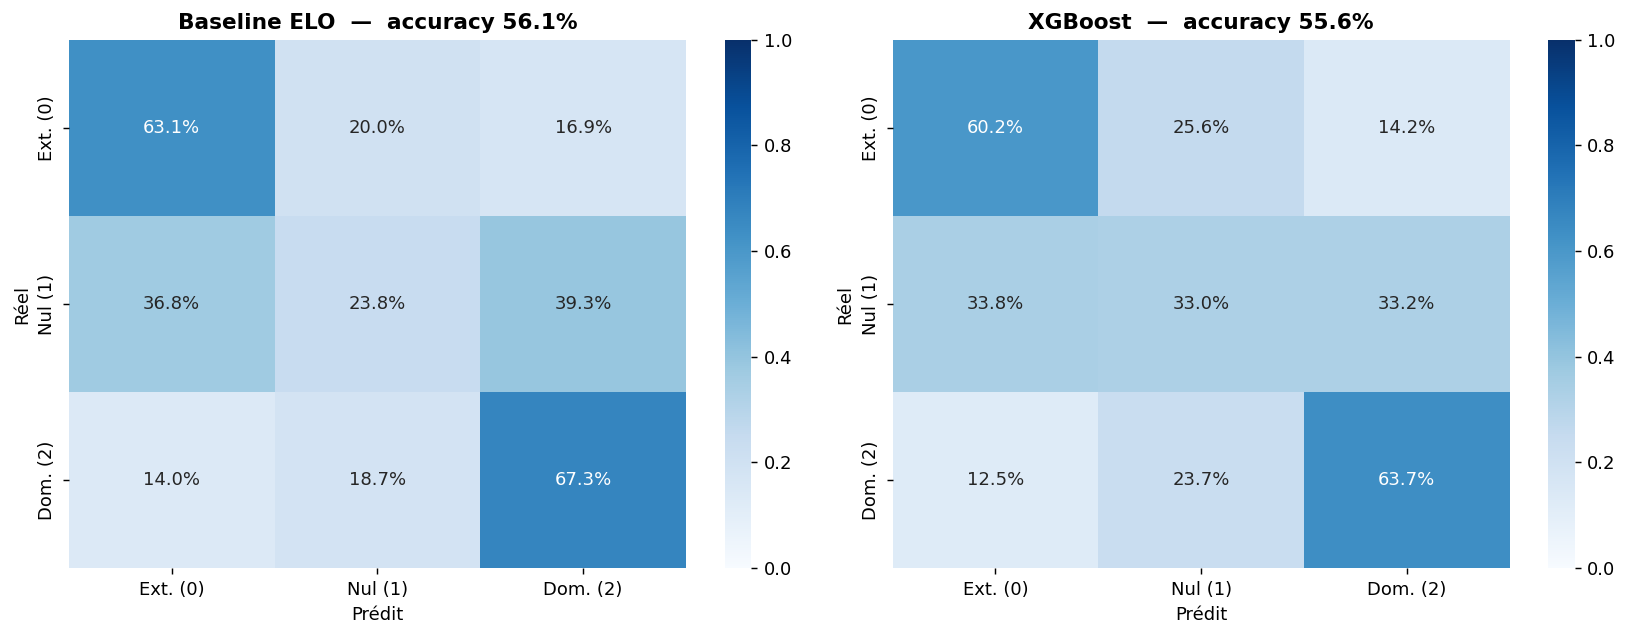

In [89]:
# Résumé des performances
summary = pd.DataFrame({
    'Accuracy': {
        'Baseline (val)':  metrics['baseline_val']['accuracy'],
        'Baseline (test)': metrics['baseline_test']['accuracy'],
        'XGBoost (val)':   metrics['xgb_val']['accuracy'],
        'XGBoost (test)':  metrics['xgb_test']['accuracy'],
    },
    'Log-loss': {
        'Baseline (val)':  '-',
        'Baseline (test)': '-',
        'XGBoost (val)':   metrics['xgb_val'].get('log_loss', '-'),
        'XGBoost (test)':  metrics['xgb_test'].get('log_loss', '-'),
    }
})
print(summary.to_string())

# Matrices de confusion côte à côte (test set uniquement)
test_df = features[features['date'] > VAL_END]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df['result'].values
labels  = ['Ext. (0)', 'Nul (1)', 'Dom. (2)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, title in zip(
    axes,
    [baseline_predict(X_test), model.predict(X_test)],
    ['Baseline ELO', 'XGBoost']
):
    cm     = confusion_matrix(y_test, preds, labels=[0, 1, 2])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_pct, annot=True, fmt='.1%', xticklabels=labels, yticklabels=labels,
                cmap='Blues', ax=ax, vmin=0, vmax=1)
    acc = (preds == y_test).mean()
    ax.set_title(f'{title}  —  accuracy {acc:.1%}', fontweight='bold')
    ax.set_ylabel('Réel')
    ax.set_xlabel('Prédit')
plt.tight_layout()
plt.show()


## Feature importance

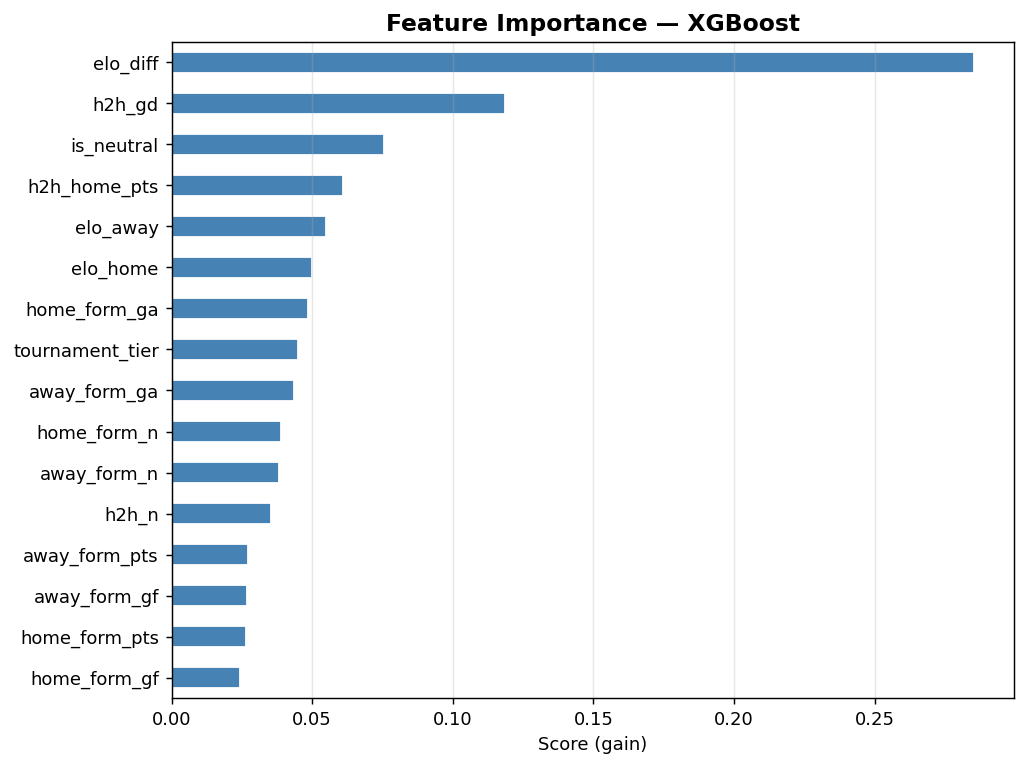

In [90]:
# Accès aux feature importances selon le type de modèle
# XGBClassifier brut → .feature_importances_ directement
# CalibratedClassifierCV → .estimator.feature_importances_
if hasattr(model, 'feature_importances_'):
    fi = model.feature_importances_
elif hasattr(model, 'estimator') and hasattr(model.estimator, 'feature_importances_'):
    fi = model.estimator.feature_importances_
else:
    raise AttributeError(f"feature_importances_ non disponible sur {type(model)}")

importance = pd.Series(fi, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance — XGBoost', fontsize=13, fontweight='bold')
ax.set_xlabel('Score (gain)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

from ml.train import TRAIN_END, VAL_END, TEST_END, baseline_predict
from ml.features import FEATURE_COLS

features_df = pd.read_csv('../../ml/data/features.csv', parse_dates=['date'])
train_df = features_df[features_df['date'] <= TRAIN_END]
val_df   = features_df[(features_df['date'] > TRAIN_END) & (features_df['date'] <= VAL_END)]
test_df  = features_df[(features_df['date'] > VAL_END)  & (features_df['date'] <= TEST_END)]
y_train, y_val, y_test = (
    train_df['result'].values, val_df['result'].values, test_df['result'].values
)

FEATURE_SETS = {
    "elo_only": [
        "elo_home", "elo_away", "elo_diff",
    ],
    "elo_context": [
        "elo_home", "elo_away", "elo_diff",
        "is_neutral", "tournament_tier",
    ],
    "elo_form": [
        "elo_home", "elo_away", "elo_diff",
        "is_neutral", "tournament_tier",
        "home_form_pts", "home_form_gf", "home_form_ga", "home_form_n",
        "away_form_pts", "away_form_gf", "away_form_ga", "away_form_n",
    ],
    "all_features": FEATURE_COLS,  # +H2H (h2h_home_pts, h2h_gd, h2h_n)
}


def _eval(y_true, preds, proba=None):
    acc = accuracy_score(y_true, preds)
    cm  = confusion_matrix(y_true, preds, labels=[0, 1, 2])
    dr  = cm[1, 1] / cm[1, :].sum() if cm[1, :].sum() else 0.0
    ll  = log_loss(y_true, proba, labels=[0, 1, 2]) if proba is not None else None
    return {"acc": acc, "ll": ll, "draw_recall": dr}


def run_xgb(cols):
    w = compute_sample_weight("balanced", y_train)
    m = XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective="multi:softprob", num_class=3,
        eval_metric="mlogloss", early_stopping_rounds=30,
        random_state=42, n_jobs=-1, verbosity=0,
    )
    m.fit(train_df[cols], y_train, sample_weight=w,
          eval_set=[(val_df[cols], y_val)], verbose=False)
    proba = m.predict_proba(test_df[cols])
    return _eval(y_test, m.predict(test_df[cols]), proba)


# Baseline ELO naïf
bl_preds = baseline_predict(test_df[FEATURE_COLS])
results  = {"baseline (ELO naïf)": _eval(y_test, bl_preds)}

# Ablation
for name, cols in FEATURE_SETS.items():
    print(f"Training {name} ({len(cols)} features)...", end=" ")
    results[name] = run_xgb(cols)
    r = results[name]
    print(f"acc={r['acc']:.4f}  ll={r['ll']:.4f}  draw_recall={r['draw_recall']:.1%}")

# Tableau
print(f"\n{'─'*65}")
print(f"  {'Set':<24} {'#':>3}  {'Accuracy':>8}  {'Log-loss':>8}  {'Recall nuls':>11}")
print(f"  {'─'*60}")
sizes = {"baseline (ELO naïf)": 1, **{k: len(v) for k, v in FEATURE_SETS.items()}}
for name, r in results.items():
    ll_str = f"{r['ll']:.4f}" if r['ll'] else "    —   "
    print(f"  {name:<24} {sizes[name]:>3}  {r['acc']:.4f}    {ll_str:>8}  {r['draw_recall']:>10.1%}")


In [ ]:
names  = list(results.keys())
accs   = [r["acc"]         for r in results.values()]
draws  = [r["draw_recall"] for r in results.values()]
colors = ["#aaaaaa"] + ["#2196F3"] * (len(names) - 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
bars1 = ax1.barh(names, accs, color=colors, edgecolor="white")
ax1.axvline(accs[0], color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax1.set_xlabel("Accuracy (test)")
ax1.set_title("Accuracy par feature set", fontweight="bold")
ax1.set_xlim(0.45, 0.60)
for bar, v in zip(bars1, accs):
    ax1.text(v + 0.001, bar.get_y() + bar.get_height()/2,
             f"{v:.3f}", va="center", fontsize=9)

# Draw recall
bars2 = ax2.barh(names, draws, color=colors, edgecolor="white")
ax2.axvline(draws[0], color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax2.set_xlabel("Recall nuls (test)")
ax2.set_title("Recall nuls par feature set", fontweight="bold")
ax2.set_xlim(0.0, 0.5)
for bar, v in zip(bars2, draws):
    ax2.text(v + 0.005, bar.get_y() + bar.get_height()/2,
             f"{v:.1%}", va="center", fontsize=9)

plt.suptitle("Ablation study — contribution marginale de chaque groupe de features",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
